Wind Speed Prediction using ST-LSTM  
Data Preprocessing & Exploratory Analysis

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

folder = r"C:\FINAL\winddata"

files = sorted([
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.lower().endswith(".csv")
])

print("Total sites:", len(files))
print(files[:5])

Total sites: 235
['C:\\FINAL\\winddata\\SITE_00001.CSV', 'C:\\FINAL\\winddata\\SITE_00002.CSV', 'C:\\FINAL\\winddata\\SITE_00002hiran.CSV', 'C:\\FINAL\\winddata\\SITE_00003.CSV', 'C:\\FINAL\\winddata\\SITE_00004.CSV']


In [2]:
def read_wind_file(path):

    with open(path, "r") as f:
        lines = f.readlines()

    start = 0
    for i, line in enumerate(lines):
        if "DATE" in line and "TIME" in line:
            start = i
            break

    df = pd.read_csv(path, skiprows=start)
    df.columns = ["DATE","TIME","WIND","POWER"]

    df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
    df["TS"] = df["DATE"] + pd.to_timedelta(df["TIME"], unit="m")

    df = df.sort_values("TS")

    df["WIND"] = pd.to_numeric(df["WIND"], errors="coerce")
    df["POWER"] = pd.to_numeric(df["POWER"], errors="coerce")

    df = df.set_index("TS")
    df = df[["WIND","POWER"]].resample("10min").mean()

    # ✅ CHECK HERE (correct place)
    missing_mask = df["WIND"].isna().astype(int)

    gap_lengths = missing_mask.groupby(
        (missing_mask != missing_mask.shift()).cumsum()
    ).sum()

    print("Missing %:", df["WIND"].isna().mean() * 100)
    print("Max gap length:", gap_lengths.max())

    # interpolation
    df["WIND"] = df["WIND"].interpolate(method="time")
    df["POWER"] = df["POWER"].interpolate(method="time")

    df = df.dropna(subset=["WIND","POWER"])
    df["WIND"] = df["WIND"].clip(lower=0)

    df = df.reset_index()

    return df

Missing %: 13.926445188189222
Max gap length: 4
                   TS  WIND  POWER
0 2004-01-01 00:10:00  6.60  46.34
1 2004-01-01 00:20:00  6.77  48.00
2 2004-01-01 00:30:00  7.17  53.37
3 2004-01-01 00:40:00  7.84  62.71
4 2004-01-01 00:50:00  8.97  79.92
(158059, 3)


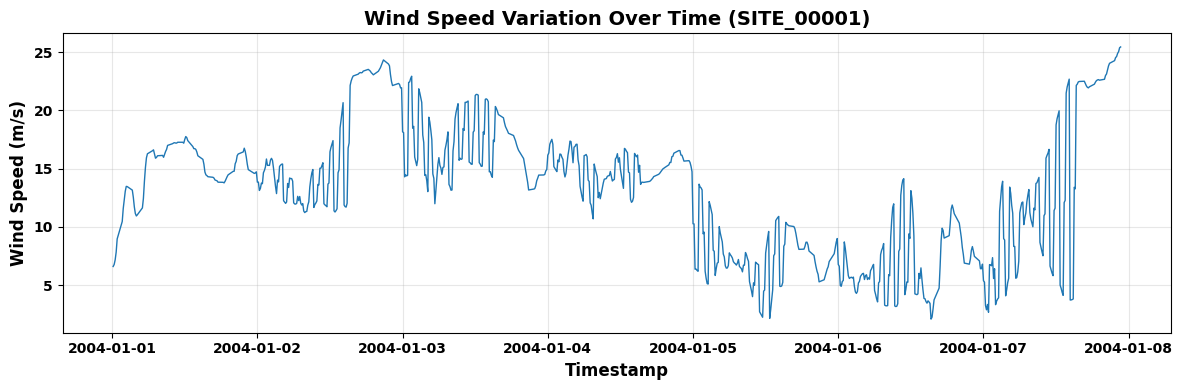

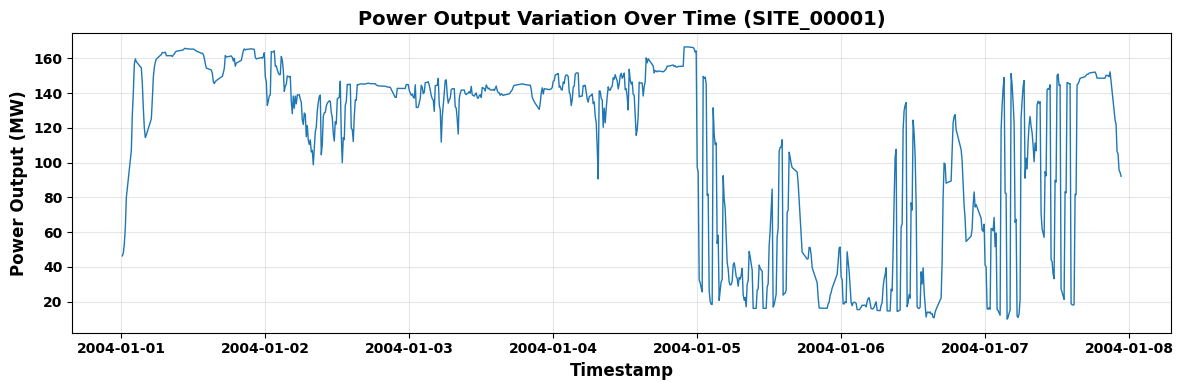

In [3]:
df = read_wind_file(files[0])

print(df.head())
print(df.shape)

sample = df.iloc[:1000]

# ---------------- WIND SPEED PLOT ----------------

plt.figure(figsize=(12,4))

plt.plot(sample["TS"], sample["WIND"], linewidth=1)

plt.xlabel(
    "Timestamp",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Wind Speed (m/s)",
    fontsize=12,
    fontweight='bold'
)

plt.title(
    "Wind Speed Variation Over Time (SITE_00001)",
    fontsize=14,
    fontweight='bold'
)

# Bold tick labels
plt.xticks(
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=10,
    fontweight='bold'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ---------------- POWER OUTPUT PLOT ----------------

plt.figure(figsize=(12,4))

plt.plot(sample["TS"], sample["POWER"], linewidth=1)

plt.xlabel(
    "Timestamp",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Power Output (MW)",
    fontsize=12,
    fontweight='bold'
)

plt.title(
    "Power Output Variation Over Time (SITE_00001)",
    fontsize=14,
    fontweight='bold'
)

# Bold tick labels
plt.xticks(
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=10,
    fontweight='bold'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [4]:
random.seed(42)
sample_sites = random.sample(files, 5)

for f in sample_sites:
    df = read_wind_file(f)
    
    print("\nSite:", f)
    print("Start:", df["TS"].iloc[0])
    print("End:", df["TS"].iloc[-1])
    print("Rows:", len(df))
    print("Duration:", df["TS"].iloc[-1] - df["TS"].iloc[0])

Missing %: 13.926445188189222
Max gap length: 4

Site: C:\FINAL\winddata\SITE_00228.CSV
Start: 2004-01-01 00:10:00
End: 2007-01-02 15:10:00
Rows: 158059
Duration: 1097 days 15:00:00
Missing %: 13.926445188189222
Max gap length: 4

Site: C:\FINAL\winddata\SITE_00037.CSV
Start: 2004-01-01 00:10:00
End: 2007-01-02 15:10:00
Rows: 158059
Duration: 1097 days 15:00:00
Missing %: 13.926445188189222
Max gap length: 4

Site: C:\FINAL\winddata\SITE_00006.CSV
Start: 2004-01-01 00:10:00
End: 2007-01-02 15:10:00
Rows: 158059
Duration: 1097 days 15:00:00
Missing %: 13.926445188189222
Max gap length: 4

Site: C:\FINAL\winddata\SITE_00264.CSV
Start: 2004-01-01 00:10:00
End: 2007-01-02 15:10:00
Rows: 158059
Duration: 1097 days 15:00:00
Missing %: 13.926445188189222
Max gap length: 4

Site: C:\FINAL\winddata\SITE_00100.CSV
Start: 2004-01-01 00:10:00
End: 2007-01-02 15:10:00
Rows: 158059
Duration: 1097 days 15:00:00


Missing %: 13.926445188189222
Max gap length: 4


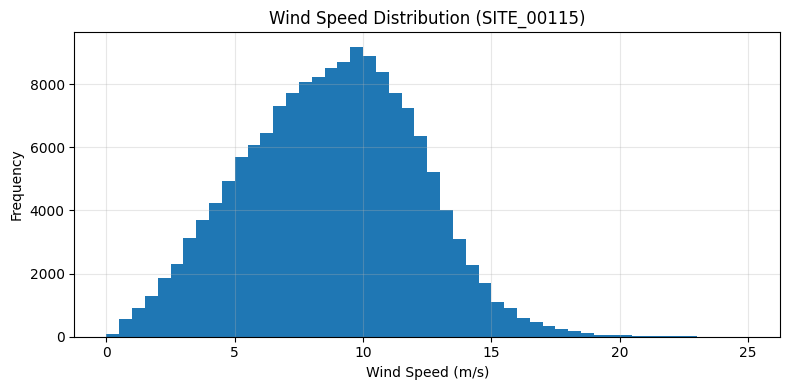

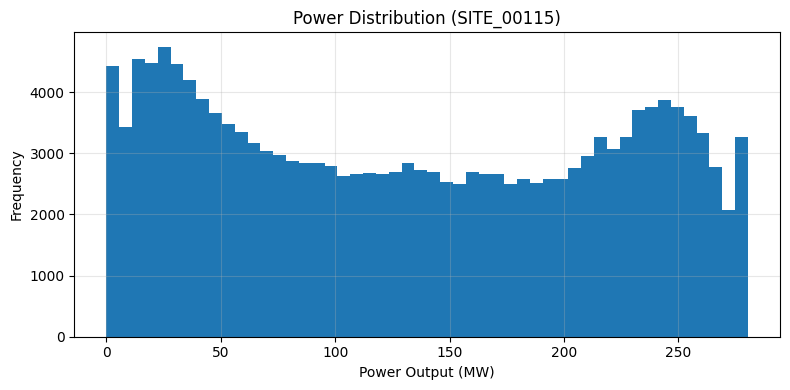

Missing %: 13.926445188189222
Max gap length: 4


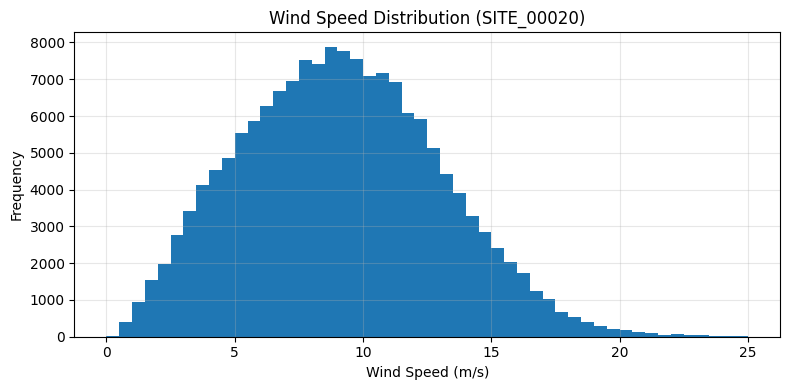

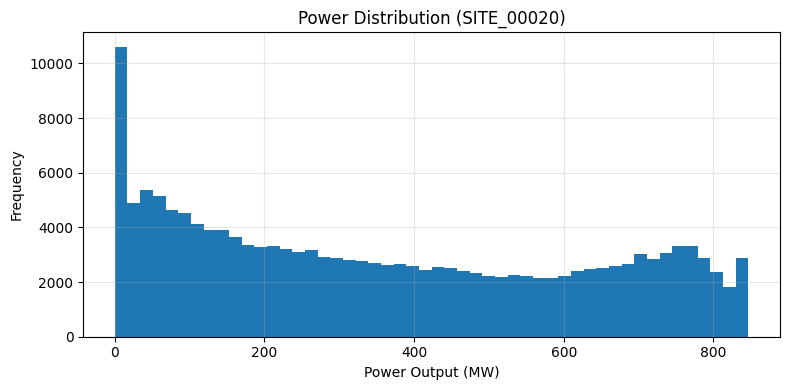

Missing %: 13.926445188189222
Max gap length: 4


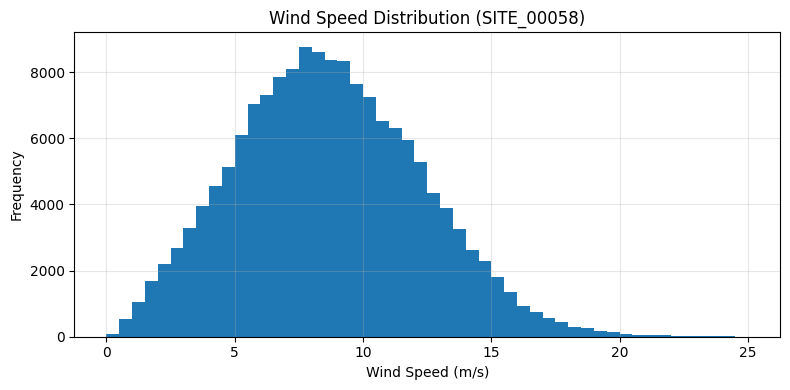

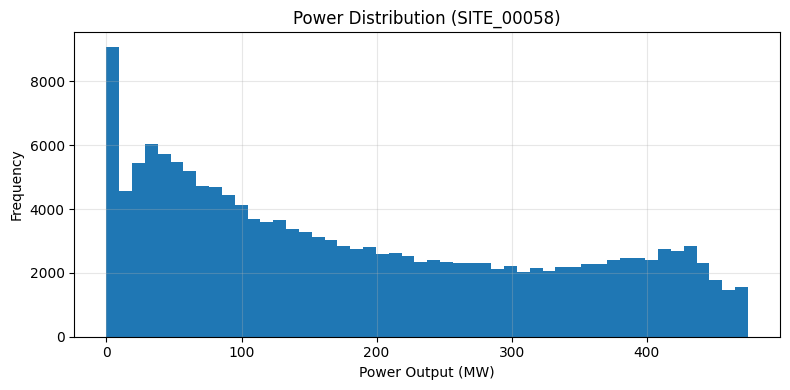

In [5]:
sites_to_plot = [
    r"C:\FINAL PROJECT\winddata\SITE_00115.CSV",
    r"C:\FINAL PROJECT\winddata\SITE_00020.CSV",
    r"C:\FINAL PROJECT\winddata\SITE_00058.CSV"
]

for f in sites_to_plot:

    df = read_wind_file(f)

    site_name = os.path.basename(f).replace(".CSV", "")

    # Wind Distribution
    plt.figure(figsize=(8,4))

    plt.hist(df["WIND"], bins=50, range=(0,25))

    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Frequency")
    plt.title(f"Wind Speed Distribution ({site_name})")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Power Distribution
    plt.figure(figsize=(8,4))

    plt.hist(df["POWER"], bins=50)

    plt.xlabel("Power Output (MW)")
    plt.ylabel("Frequency")
    plt.title(f"Power Distribution ({site_name})")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 23.829787234042556
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4


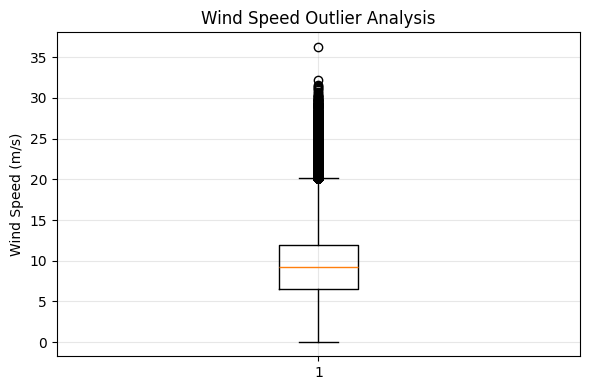

In [6]:
all_wind = []

for f in files[:20]:  # small sample for speed
    temp = read_wind_file(f)
    all_wind.extend(temp["WIND"].values)

plt.figure(figsize=(6,4))

plt.boxplot(all_wind)

plt.ylabel("Wind Speed (m/s)")
plt.title("Wind Speed Outlier Analysis")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Missing %: 13.926445188189222
Max gap length: 4


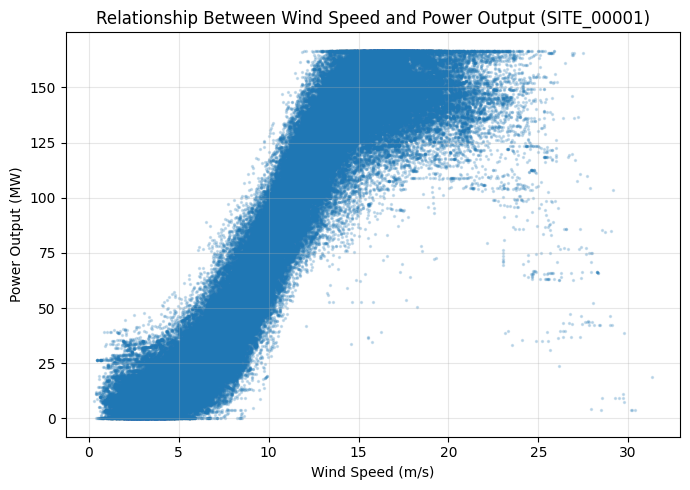

Correlation: 0.9234454331975473


In [7]:
df = read_wind_file(files[0])

plt.figure(figsize=(7,5))

plt.scatter(
    df["WIND"],
    df["POWER"],
    s=2,
    alpha=0.2
)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (MW)")
plt.title("Relationship Between Wind Speed and Power Output (SITE_00001)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("Correlation:", df["WIND"].corr(df["POWER"]))

Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4


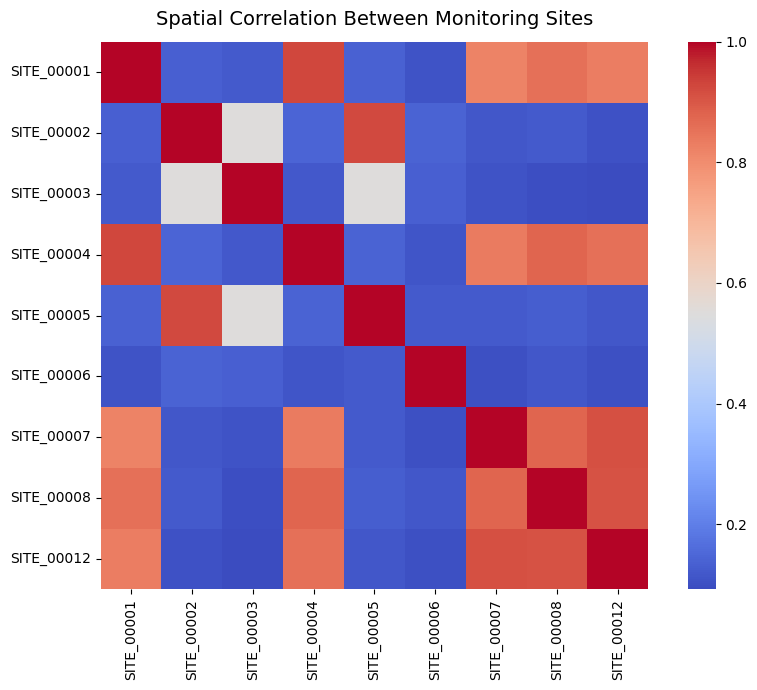

In [8]:
import seaborn as sns

site_data = {}

selected_files = [
    f for f in files[:10]
    if "hiran" not in f.lower()
]
min_length = float("inf")

# First pass: find minimum length
for f in selected_files:

    df = read_wind_file(f)

    min_length = min(min_length, len(df))

# Second pass: trim all to same length
for f in selected_files:

    df = read_wind_file(f)

    site_name = os.path.basename(f).replace(".CSV","")

    site_data[site_name] = df["WIND"].values[:min_length]

corr_df = pd.DataFrame(site_data)

corr_matrix = corr_df.corr()

plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    square =True
)

plt.title(
    "Spatial Correlation Between Monitoring Sites",
    fontsize=14,
    pad=12
)
plt.tight_layout()
plt.show()

Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4
Missing %: 13.926445188189222
Max gap length: 4


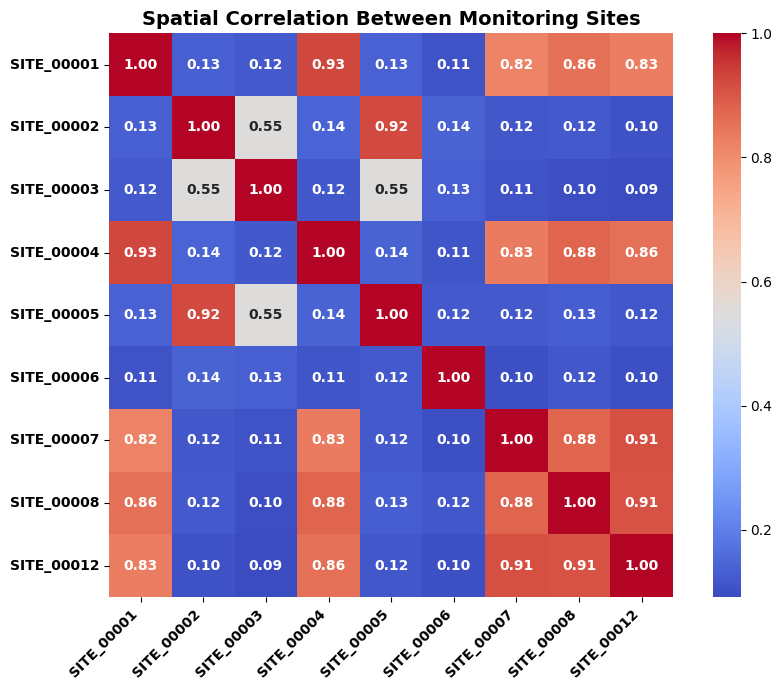

In [9]:
import seaborn as sns

site_data = {}

selected_files = [
    f for f in files[:10]
    if "hiran" not in f.lower()
]

min_length = float("inf")

# First pass: find minimum length
for f in selected_files:

    df = read_wind_file(f)

    min_length = min(min_length, len(df))

# Second pass: trim all to same length
for f in selected_files:

    df = read_wind_file(f)

    site_name = os.path.basename(f).replace(".CSV","")

    site_data[site_name] = df["WIND"].values[:min_length]

corr_df = pd.DataFrame(site_data)

corr_matrix = corr_df.corr()

plt.figure(figsize=(9,7))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    annot_kws={
        "fontsize":10,
        "fontweight":"bold"
    }
)

plt.title(
    "Spatial Correlation Between Monitoring Sites",
    fontsize=14,
    fontweight='bold'
)

# Bold site names
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10,
    fontweight='bold'
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout()

plt.show()